In [1]:
import pathlib

import pandas as pd

In [2]:
output_folder = pathlib.Path("../../data/outputs_nosync/outputs_leaf/") # Change this for different outputs
prediction_runs = [fol for fol in output_folder.iterdir() if fol.is_dir()]
prediction_runs

[PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_f_1000')]

In [3]:
output_folder2 = pathlib.Path("../../data/outputs_combined/") # Change this for different outputs
prediction_runs2 = [fol for fol in output_folder2.iterdir() if fol.is_dir()]
prediction_runs2

[PosixPath('../../data/outputs_combined/biolog_mutual_info_1000')]

In [4]:
def read_csv_files(folder_list: list[pathlib.Path], file_name: str, reindex: bool = True):
    df_list = []
    for folder in folder_list:
        file_path = folder / file_name
        df = pd.read_csv(file_path, index_col=0)
        df_list.append(df)
    df_concat = pd.concat(df_list)
    if reindex:
        df_concat.index = list(range(df_concat.shape[0])) # type: ignore
    return df_concat

In [5]:
cv_scores_df1 = read_csv_files(prediction_runs, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df1

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,1,cluster30,biolog_mutual_info_1000
1,0.950000,0.972222,0.666667,1.000000,0.800000,0.958333,0.793492,Oxalate,leaf_biolog,2,cluster30,biolog_mutual_info_1000
2,0.950000,0.861111,0.750000,0.750000,0.750000,0.972222,0.722222,Oxalate,leaf_biolog,3,cluster30,biolog_mutual_info_1000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,4,cluster30,biolog_mutual_info_1000
4,0.975000,0.875000,1.000000,0.750000,0.857143,1.000000,0.854242,Oxalate,leaf_biolog,5,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
14395,0.875000,0.772727,1.000000,0.545455,0.705882,0.962382,0.682086,myo_inositol,leaf_biolog,1,uniref90,biolog_f_1000
14396,0.825000,0.732143,0.857143,0.500000,0.631579,0.922619,0.559950,myo_inositol,leaf_biolog,2,uniref90,biolog_f_1000
14397,0.800000,0.738095,0.700000,0.583333,0.636364,0.901786,0.503953,myo_inositol,leaf_biolog,3,uniref90,biolog_f_1000
14398,0.871795,0.772727,1.000000,0.545455,0.705882,0.944805,0.680301,myo_inositol,leaf_biolog,4,uniref90,biolog_f_1000


In [6]:
cv_scores_df2 = read_csv_files(prediction_runs2, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df2

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,0.972973,0.833333,1.000000,0.666667,0.800000,1.000000,0.804748,Oxalate,leaf_biolog,1,combined,biolog_mutual_info_1000
1,0.945946,0.970588,0.600000,1.000000,0.750000,0.980392,0.751469,Oxalate,leaf_biolog,2,combined,biolog_mutual_info_1000
2,0.972973,0.984848,0.800000,1.000000,0.888889,0.969697,0.880771,Oxalate,leaf_biolog,3,combined,biolog_mutual_info_1000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,4,combined,biolog_mutual_info_1000
4,0.972222,0.833333,1.000000,0.666667,0.800000,1.000000,0.804400,Oxalate,leaf_biolog,5,combined,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.973684,0.954545,1.000000,0.909091,0.952381,0.993266,0.936282,myo_inositol,leaf_biolog,1,combined,biolog_mutual_info_1000
196,0.973684,0.981481,0.916667,1.000000,0.956522,0.993266,0.939530,myo_inositol,leaf_biolog,2,combined,biolog_mutual_info_1000
197,0.973684,0.954545,1.000000,0.909091,0.952381,1.000000,0.936282,myo_inositol,leaf_biolog,3,combined,biolog_mutual_info_1000
198,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,myo_inositol,leaf_biolog,4,combined,biolog_mutual_info_1000


In [7]:
cv_scores_df = pd.concat([cv_scores_df1[cv_scores_df1.run_id == "biolog_mutual_info_1000"], cv_scores_df2])
cv_scores_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,1,cluster30,biolog_mutual_info_1000
1,0.950000,0.972222,0.666667,1.000000,0.800000,0.958333,0.793492,Oxalate,leaf_biolog,2,cluster30,biolog_mutual_info_1000
2,0.950000,0.861111,0.750000,0.750000,0.750000,0.972222,0.722222,Oxalate,leaf_biolog,3,cluster30,biolog_mutual_info_1000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,4,cluster30,biolog_mutual_info_1000
4,0.975000,0.875000,1.000000,0.750000,0.857143,1.000000,0.854242,Oxalate,leaf_biolog,5,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.973684,0.954545,1.000000,0.909091,0.952381,0.993266,0.936282,myo_inositol,leaf_biolog,1,combined,biolog_mutual_info_1000
196,0.973684,0.981481,0.916667,1.000000,0.956522,0.993266,0.939530,myo_inositol,leaf_biolog,2,combined,biolog_mutual_info_1000
197,0.973684,0.954545,1.000000,0.909091,0.952381,1.000000,0.936282,myo_inositol,leaf_biolog,3,combined,biolog_mutual_info_1000
198,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,myo_inositol,leaf_biolog,4,combined,biolog_mutual_info_1000


In [8]:

score_columns = ["balanced_accuracy", "matthews_corrcoef", "accuracy",  "f1", "precision", "recall", "roc_auc" ]

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/dileep/Documents/Work/trait-prediction

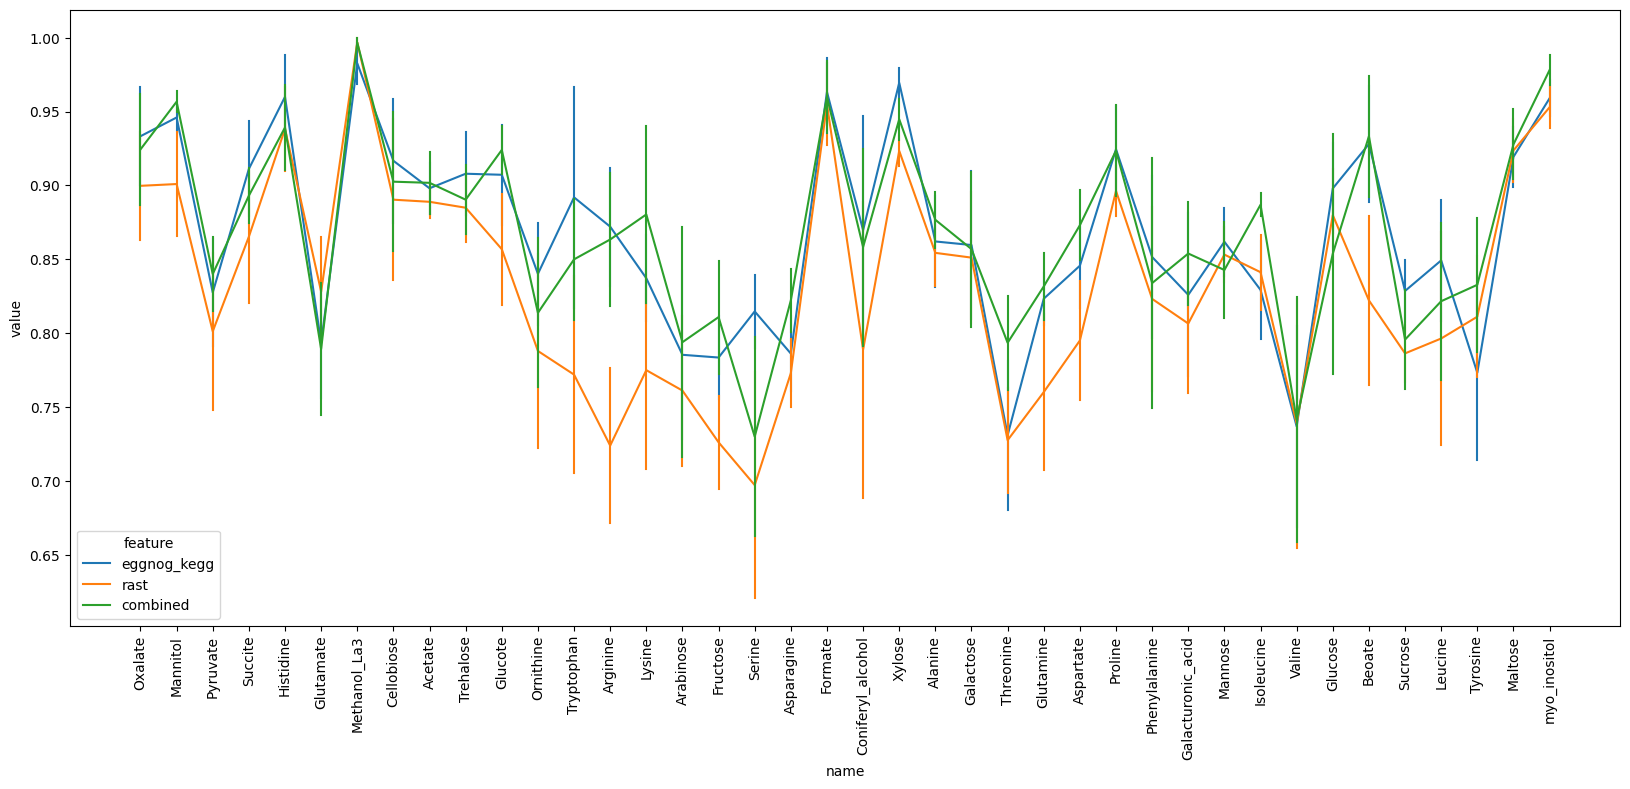

In [10]:
cols = score_columns
plot_data = (
    cv_scores_df
    .melt(id_vars=["name", "feature"], value_vars=score_columns, var_name="score", value_name="value")
)
plot_data = plot_data[plot_data.score.isin(["balanced_accuracy"])]
plot_data = plot_data[plot_data.feature.isin(["eggnog_kegg", "combined", "rast"])]

plt.figure(figsize=(20,8))
sns.lineplot(data=plot_data, x="name", y="value", errorbar="se", err_style="bars",  hue="feature")
plt.tick_params(axis='x', rotation=90, which="both");
# for i, ax in enumerate(g.axes.flat):
#     ax.tick_params(axis='x', rotation=90, which="both");

> NOTE:
> The lower performance of the combined dataset on some of the phenotypes could be because it has 20 fewer data points (i.e. 10% fewer) compared to the original dataset!

In [11]:
from matplotlib.patches import Rectangle

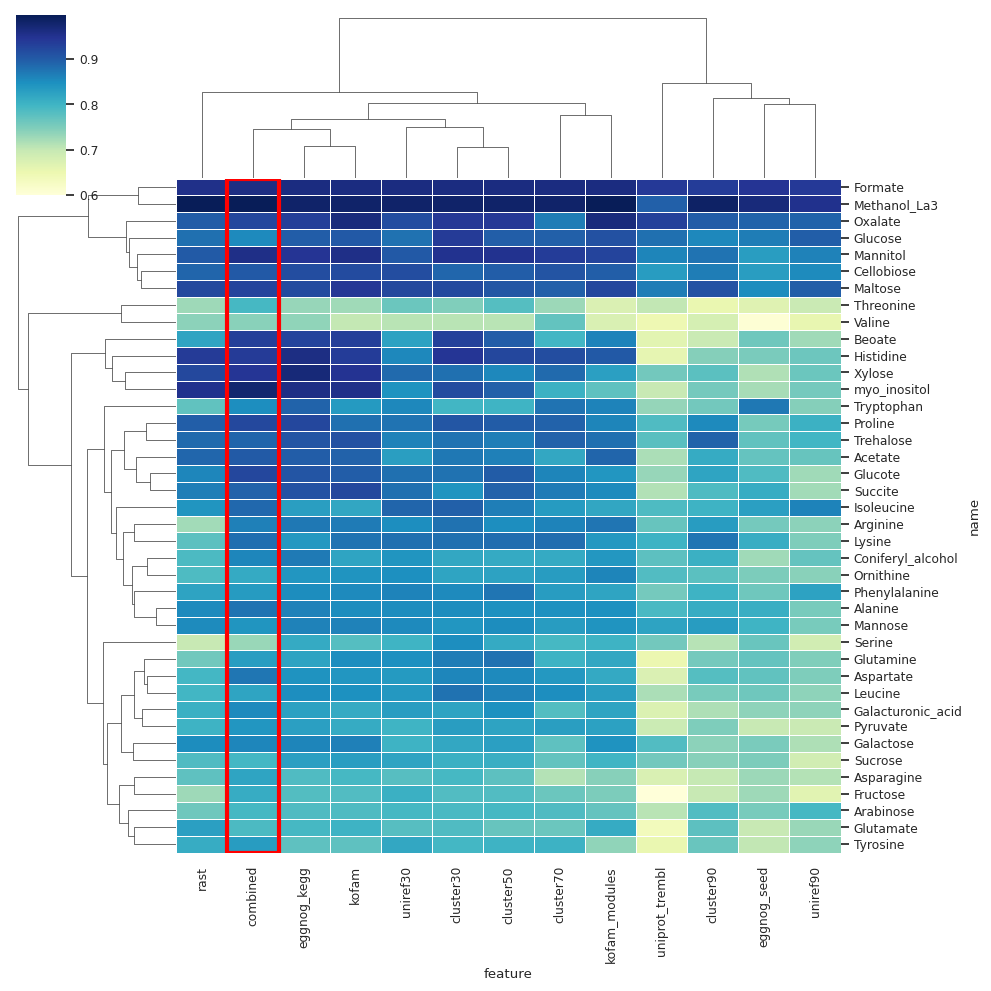

In [12]:
plot_data = (
    cv_scores_df
    .loc[cv_scores_df.run_id == "biolog_mutual_info_1000", ["feature", "name", "balanced_accuracy"]]
    .groupby(by=["feature", "name"])
    .mean()
    .reset_index()
    .sort_values(by="balanced_accuracy", ascending=False)
    .pivot(index="name", columns="feature", values="balanced_accuracy")
)
sns.set_theme(font_scale=0.8)
g = sns.clustermap(plot_data,  linewidths=.5, cmap="YlGnBu", yticklabels=1)
ax = g.ax_heatmap

ax.add_patch(Rectangle((1, 0), 1, 40, fill=False, edgecolor='red', lw=3))
plt.show()

In [13]:
def common_features(group):
    df = group.drop(["fold_num", "category", "feature", "run_id", "name"], axis=1)
    n = df.shape[0]
    m = df.shape[1]
    feature_list = []
    for i in range(n):
        feature_list.append(set(df.iloc[i]))
    common_features = set.intersection(*feature_list)
    return len(common_features) / m * 100

In [14]:
cv_features_df = read_csv_files(prediction_runs2, "all_feat_cv_features_data.csv", reindex=True)
cv_features_df

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_16,feat_17,feat_18,feat_19,feat_20,fold_num,feature,run_id,name,category
0,UniRef30_UPI001FBBBACB,SSO:000020952,70_2476,SSO:000002901,K20997,SSO:000008135,UniRef30_A0A8J2UVD6,K00616,K01561,UniRef30_A0A212QZ53,...,91_1699,SSO:000041006,607_914,1152_3516,8_1302,1,combined,biolog_mutual_info_1000,Oxalate,leaf_biolog
1,SSO:000020952,UniRef30_UPI001FBBBACB,SSO:000002901,1152_3516,K20997,70_2476,311_702.2,SSO:000014978,SSO:000041746,SSO:000035928,...,K07334.1,635_1521,494_1504,K05916,UniRef30_A0A318EDN9,2,combined,biolog_mutual_info_1000,Oxalate,leaf_biolog
2,UniRef30_UPI001FBBBACB,SSO:000020952,632_3349,954_2077,SSO:000028963,SSO:000012236,929_2405,K01455.1,K20034,SSO:000002901,...,UniRef30_A0A327K9S7,843_1091,SSO:000012337,K03926,889_1436,3,combined,biolog_mutual_info_1000,Oxalate,leaf_biolog
3,SSO:000002901,UniRef90_A0A0Q4X7X9,SSO:000014978,SSO:000018954,SSO:000035928,607_914.1,UniRef30_A0A2H6J2B8,K20997,SSO:000012236,545_4337,...,SSO:000021897,SSO:000012337,871_6671,891_1471,216_5423,4,combined,biolog_mutual_info_1000,Oxalate,leaf_biolog
4,311_702.2,311_702,K20997,1282_5283,UniRef30_UPI00141E5261,SSO:000020952,K01577,K08070,UniRef30_UPI001EDDEABA,K01455.1,...,K13810.1,SSO:000008863,K18096,1312_4039,1399_1056,5,combined,biolog_mutual_info_1000,Oxalate,leaf_biolog
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,K03337,K03338,K00010,K03335.1,SSO:000034095,K03335,27_3461,434_1597,1289_1577,882_4298,...,SSO:000018761,K06605,K16953,K02058,K02058.1,1,combined,biolog_mutual_info_1000,myo_inositol,leaf_biolog
196,K03338,K03337,SSO:000034095,K03335.1,K03335,K00010,27_3461,UniRef30_UPI001C974D9D,1019_506,700_2134,...,882_4298,57_271,K10440,K07794,K06605,2,combined,biolog_mutual_info_1000,myo_inositol,leaf_biolog
197,K03337,SSO:000034095,K00010,K03335.1,K03338,K03335,K10439,882_4298,122_4385,K10440,...,K06605,UniRef30_A0A852T2Q7,SSO:000003238,K01820,SSO:000034238,3,combined,biolog_mutual_info_1000,myo_inositol,leaf_biolog
198,K03337,K03338,K03335,K03335.1,K00010,SSO:000034095,882_4298,K11755,991.IW20_15330,1289_1577,...,K10439,700_2134,SSO:000001198,K06605,K02057,4,combined,biolog_mutual_info_1000,myo_inositol,leaf_biolog


/tmp/ipykernel_542417/532998193.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_data = cv_features_df.groupby(by=["name"]).apply(common_features).reset_index()


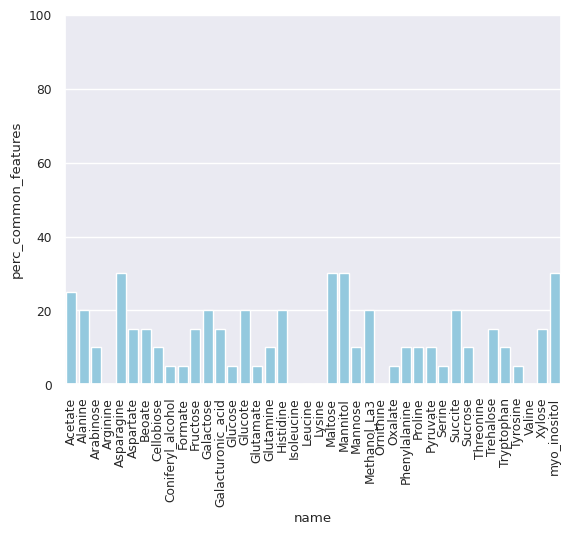

In [15]:
plot_data = cv_features_df.groupby(by=["name"]).apply(common_features).reset_index()
plot_data.columns = ["name", "perc_common_features"]
g = sns.barplot(data=plot_data, x="name", y="perc_common_features", color="skyblue")
plt.ylim(0, 100)
plt.tick_params(axis='x', rotation=90, which="both");
# for ax in g.axes.flat:
#     ax.tick_params(axis='x', rotation=90, which="both");

> NOTE:
> The low number of common features is probably because of the high correlation about the features in the combined dataset.